In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
%matplotlib inline

In [3]:
df = pd.read_csv("ds2.csv")

In [4]:
df.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,8,0,18,7,30,3,2026-06-23,3,0,86


In [5]:
df['churn'] = [1 if value < 1 else 0 for value in df['return_frequency']]

In [6]:
df.describe()

,user_id,age,income_level,has_children,household_size,weekly_purchases,monthly_spend,cart_abandonment_rate,review_writing_frequency,average_order_value,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,social_sharing_frequency,premium_subscription,return_rate,churn
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,49.003377,104994.565463,0.399426,5.505323,9.993011,2498.775654,40.212257,3.450584,255.031632,...,5.494336,4.997523,50.001442,3.498840,49.989012,12.509560,3.593763,0.359415,50.004949,0.076803
std,288675.278933,18.193959,54851.476652,0.489781,2.873725,6.055124,1444.208674,25.433343,1.856725,141.708466,...,2.870467,3.162831,29.163437,2.291567,29.151948,6.922197,1.932566,0.479829,29.159616,0.266279
min,1.000000,18.000000,10000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,250000.750000,33.000000,57466.000000,0.000000,3.000000,5.000000,1249.000000,18.000000,2.000000,132.000000,...,3.000000,2.000000,25.000000,1.000000,25.000000,7.000000,2.000000,0.000000,25.000000,0.000000
50%,500000.500000,49.000000,105013.000000,0.000000,6.000000,10.000000,2498.000000,40.000000,3.000000,255.000000,...,5.000000,5.000000,50.000000,3.000000,50.000000,13.000000,4.000000,0.000000,50.000000,0.000000
75%,750000.250000,65.000000,152497.000000,1.000000,8.000000,15.000000,3750.000000,62.000000,5.000000,378.000000,...,8.000000,8.000000,75.000000,6.000000,75.000000,19.000000,5.000000,1.000000,75.000000,0.000000
max,1000000.000000,80.000000,200000.000000,1.000000,10.000000,20.000000,5000.000000,90.000000,8.000000,500.000000,...,10.000000,10.000000,100.000000,7.000000,100.000000,24.000000,8.000000,1.000000,100.000000,1.000000


In [7]:
categorical_cols = ['gender', 'country', 'urban_rural', 'employment_status', 'education_level',
                    'relationship_status', 'has_children', 'occupation', 'ethnicity',
                    'language_preference', 'device_type', 'preferred_payment_method', 
                    'loyalty_program_member', 'product_category_preference', 'shopping_time_of_day', 
                    'weekend_shopper', 'budgeting_style', 'health_conscious_shopping', 'premium_subscription']
#removed 'last_purchase_date' from categorical_cols

In [8]:
encoder = LabelEncoder()
for each_col in categorical_cols:
    df[each_col] = encoder.fit_transform(df[each_col])

In [9]:
df.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate,churn
0,1,56,0,5,1,90860,2,0,3,0,...,2,62,7,74,19,2025-06-22,6,1,50,0
1,2,69,1,7,1,35423,4,1,3,1,...,7,54,5,23,8,2026-07-25,3,0,37,0
2,3,46,0,6,2,21467,2,0,2,1,...,3,33,7,12,13,2026-02-26,6,0,53,0
3,4,32,1,2,2,41770,2,1,4,0,...,9,26,4,19,9,2026-10-27,7,0,98,0
4,5,60,0,7,2,183882,0,0,4,1,...,0,18,7,30,3,2026-06-23,3,0,86,0


In [ ]:
plt.figure(figsize=(38, 38))
sns.heatmap(df.corr().abs(), annot = True, cmap ='coolwarm');

In [11]:
df1 = pd.read_csv("ds2.csv")

In [12]:
df1.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,8,0,18,7,30,3,2026-06-23,3,0,86


In [13]:
df1['churn'] = [1 if value < 1 else 0 for value in df1['return_frequency']]

In [14]:
df1.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate,churn
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,2,62,7,74,19,2025-06-22,6,1,50,0
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,7,54,5,23,8,2026-07-25,3,0,37,0
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,33,7,12,13,2026-02-26,6,0,53,0
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,9,26,4,19,9,2026-10-27,7,0,98,0
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,0,18,7,30,3,2026-06-23,3,0,86,0


In [37]:
#dropping all numerical columns AND user_id
cat_split = df1.drop(columns = ['user_id', 'age', 'income_level', 'household_size', 'weekly_purchases' , 'monthly_spend' , 'cart_abandonment_rate' , 
                                'review_writing_frequency' , 'average_order_value' , 'coupon_usage_frequency' , 'referral_count' , 'impulse_purchases_per_month' , 
                                'browse_to_buy_ratio' , 'return_frequency' , 'brand_loyalty_score' , 'impulse_buying_score' , 'environmental_consciousness' , 
                                'travel_frequency' , 'hobby_count', 'social_media_influence_score' ,'reading_habits' , 'exercise_frequency' , 
                                'stress_from_financial_decisions' , 'overall_stress_level' , 'sleep_quality' , 'physical_activity_level' , 
                                'mental_health_score' , 'daily_session_time_minutes' , 'product_views_per_day' , 'ad_views_per_day' , 
                                'ad_clicks_per_day' , 'wishlist_items_count' , 'cart_items_average' , 'checkout_abandonments_per_month' , 'purchase_conversion_rate' , 
                                'app_usage_frequency' , 'notification_response_rate' , 'account_age_months' , 'social_sharing_frequency'])

In [16]:
cat_split.head()

,gender,country,urban_rural,employment_status,education_level,relationship_status,has_children,occupation,ethnicity,language_preference,...,preferred_payment_method,loyalty_program_member,product_category_preference,shopping_time_of_day,weekend_shopper,budgeting_style,health_conscious_shopping,premium_subscription,return_rate,churn
0,Female,Germany,Suburban,Self-employed,Associate Degree,Single,0,Healthcare,Other,English,...,PayPal,1,Groceries,Morning,1,Strict,1,1,50,0
1,Male,Japan,Suburban,Unemployed,Bachelor,Single,1,Finance,Other,Mandarin,...,Google Pay,1,Groceries,Afternoon,1,Loose,1,0,37,0
2,Female,India,Urban,Self-employed,Associate Degree,Married,1,Healthcare,Other,Hindi,...,PayPal,0,Beauty,Afternoon,0,Moderate,1,0,53,0
3,Male,Canada,Urban,Self-employed,Bachelor,Widowed,0,Engineering,Hispanic,Hindi,...,Credit Card,1,Groceries,Afternoon,1,Moderate,1,0,98,0
4,Female,Japan,Urban,Employed,Associate Degree,Widowed,1,Other,Asian,English,...,Apple Pay,1,Groceries,Evening,0,Loose,0,0,86,0


In [17]:
cat_split.columns

Index(['gender', 'country', 'urban_rural', 'employment_status',
       'education_level', 'relationship_status', 'has_children', 'occupation',
       'ethnicity', 'language_preference', 'device_type',
       'preferred_payment_method', 'loyalty_program_member',
       'product_category_preference', 'shopping_time_of_day',
       'weekend_shopper', 'budgeting_style', 'health_conscious_shopping',
       'premium_subscription', 'return_rate', 'churn'],
      dtype='object')

In [34]:
#run encoder on categorical columns to make them numerical
encoder = LabelEncoder()
for each_col in categorical_cols:
    cat_split[each_col] = encoder.fit_transform(cat_split[each_col])

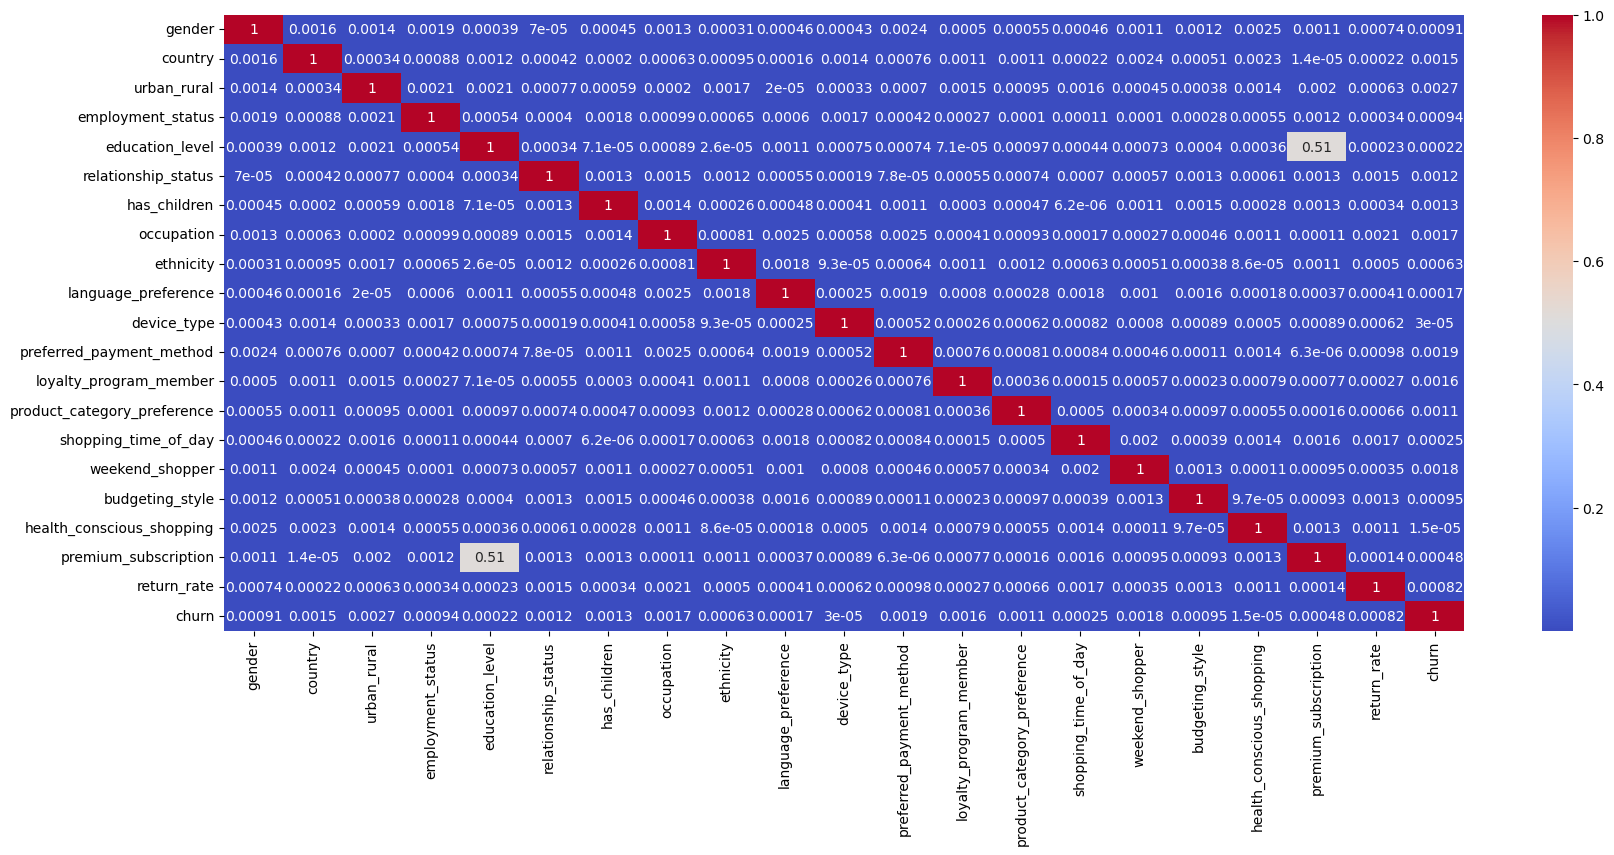

In [22]:
plt.figure(figsize=(20, 8))
sns.heatmap(cat_split.corr().abs(), annot = True, cmap ='coolwarm');

AND

In [19]:
df2 = pd.read_csv("ds2.csv")

In [32]:
#drop all cat columns and date and user_id

num_split1 = df2.drop(columns = ['user_id', 'gender', 'country', 'urban_rural', 'employment_status', 'education_level',
                    'relationship_status', 'has_children', 'occupation', 'ethnicity',
                    'language_preference', 'device_type', 'preferred_payment_method', 
                    'loyalty_program_member', 'product_category_preference', 'shopping_time_of_day', 
                    'weekend_shopper', 'budgeting_style', 'health_conscious_shopping', 'premium_subscription'])

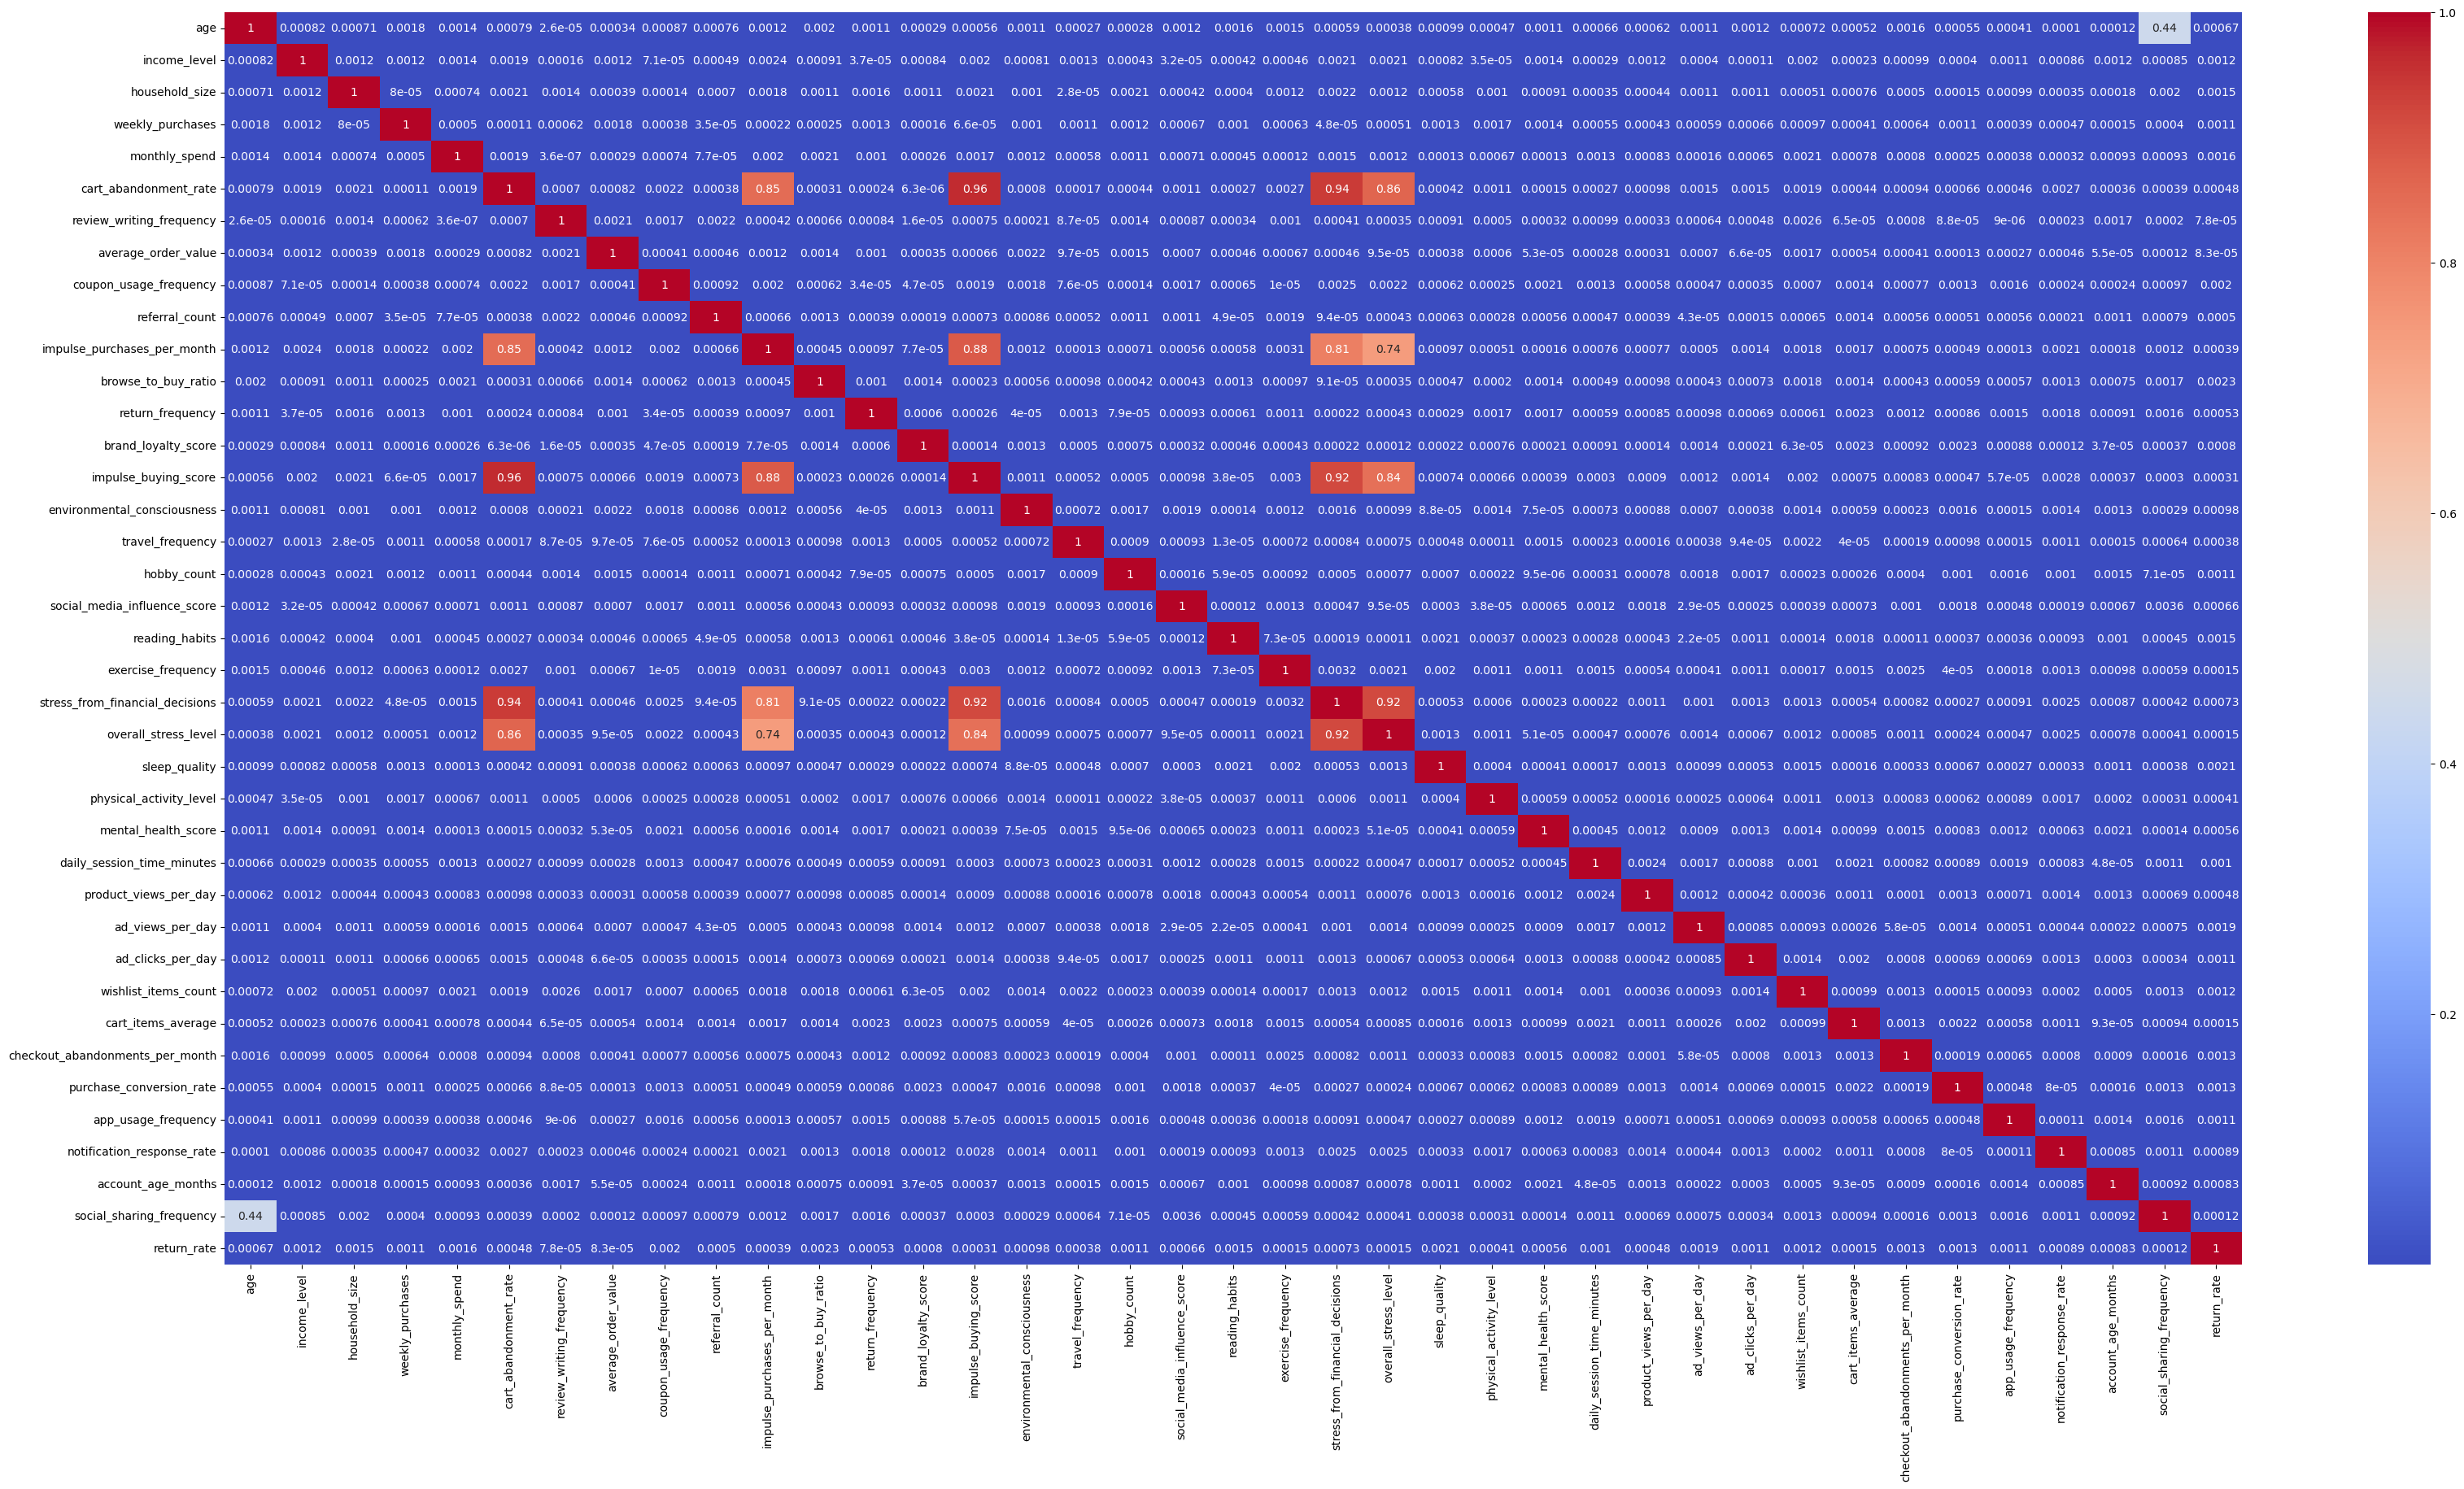

In [21]:
plt.figure(figsize=(40, 20))
sns.heatmap(num_split1.corr().abs(), annot = True, cmap ='coolwarm');

In [24]:
df.describe()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,social_sharing_frequency,premium_subscription,return_rate,churn
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,49.003377,0.580089,4.494579,1.300445,104994.565463,2.000177,1.547704,1.998136,0.399426,...,5.494336,4.997523,50.001442,3.498840,49.989012,12.509560,3.593763,0.359415,50.004949,0.076803
std,288675.278933,18.193959,0.634865,2.872416,0.780859,54851.476652,1.414584,1.117546,1.415148,0.489781,...,2.870467,3.162831,29.163437,2.291567,29.151948,6.922197,1.932566,0.479829,29.159616,0.266279
min,1.000000,18.000000,0.000000,0.000000,0.000000,10000.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,250000.750000,33.000000,0.000000,2.000000,1.000000,57466.000000,1.000000,1.000000,1.000000,0.000000,...,3.000000,2.000000,25.000000,1.000000,25.000000,7.000000,2.000000,0.000000,25.000000,0.000000
50%,500000.500000,49.000000,1.000000,4.000000,2.000000,105013.000000,2.000000,1.000000,2.000000,0.000000,...,5.000000,5.000000,50.000000,3.000000,50.000000,13.000000,4.000000,0.000000,50.000000,0.000000
75%,750000.250000,65.000000,1.000000,7.000000,2.000000,152497.000000,3.000000,2.000000,3.000000,1.000000,...,8.000000,8.000000,75.000000,6.000000,75.000000,19.000000,5.000000,1.000000,75.000000,0.000000
max,1000000.000000,80.000000,3.000000,9.000000,2.000000,200000.000000,4.000000,4.000000,4.000000,1.000000,...,10.000000,10.000000,100.000000,7.000000,100.000000,24.000000,8.000000,1.000000,100.000000,1.000000


In [55]:
#separate into X and y
X = df.drop(['churn', 'user_id'], axis = 1)
y = df['churn']

In [36]:
X

,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,household_size,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,56,0,5,1,90860,2,0,3,0,5,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,69,1,7,1,35423,4,1,3,1,2,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,46,0,6,2,21467,2,0,2,1,6,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,32,1,2,2,41770,2,1,4,0,4,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,60,0,7,2,183882,0,0,4,1,9,...,8,0,18,7,30,3,2026-06-23,3,0,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,36,0,4,2,192880,3,3,1,0,5,...,4,3,26,2,50,21,2025-06-27,2,1,93
999996,37,1,2,2,197111,4,3,0,0,8,...,10,9,31,5,78,15,2025-06-05,7,1,97
999997,71,1,8,2,171275,4,1,2,1,1,...,6,5,19,7,8,16,2026-09-25,5,0,96
999998,30,0,5,2,124983,0,2,3,0,8,...,4,2,56,5,8,11,2026-10-25,2,0,46


In [53]:
df = df.drop('last_purchase_date', axis = 1)

In [58]:
corr_matrix = X.corr()


# Identify pairs of features with high collinearity (correlation > 0.8 or < -0.8).
high_corr_features = [(col1, col2, corr_matrix.loc[col1, col2])
                     for col1 in corr_matrix.columns
                     for col2 in corr_matrix.columns
                     if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > 0.8]


# Convert to a DataFrame for better visualization.
collinearity_df = pd.DataFrame(high_corr_features, columns=["Feature 1", "Feature 2", "Correlation"])
print("\nHighly Correlated Features:\n", collinearity_df)


# Compute Variance Inflation Factor (VIF) for each feature.
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


# Print VIF values.
print("\nVariance Inflation Factor (VIF) for each feature:\n", vif_data)


Highly Correlated Features:
                           Feature 1                        Feature 2  \
0             cart_abandonment_rate      impulse_purchases_per_month   
1             cart_abandonment_rate             impulse_buying_score   
2             cart_abandonment_rate  stress_from_financial_decisions   
3             cart_abandonment_rate             overall_stress_level   
4       impulse_purchases_per_month            cart_abandonment_rate   
5       impulse_purchases_per_month             impulse_buying_score   
6       impulse_purchases_per_month  stress_from_financial_decisions   
7              impulse_buying_score            cart_abandonment_rate   
8              impulse_buying_score      impulse_purchases_per_month   
9              impulse_buying_score  stress_from_financial_decisions   
10             impulse_buying_score             overall_stress_level   
11  stress_from_financial_decisions            cart_abandonment_rate   
12  stress_from_financial_decision

In [ ]:
#remove 6 columns with VIF above 10 to mitigate multicollinearity

X = X.drop(columns = ['cart_abandonment_rate','impulse_purchases_per_month', 
                  'impulse_buying_score', 'stress_from_financial_decisions', 
                  'overall_stress_level', 'sleep_quality'])

In [ ]:
#bb